In [23]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import json


In [24]:

# Load model and class indices
model = load_model("animal_classifier_model.h5")
with open("class_indices.json", "r") as f:
    class_indices = json.load(f)
index_to_class = {v: k for k, v in class_indices.items()}

In [33]:
# Load and preprocess image
img_path = r'D:\Internship Project\Animal Classification\dataset\Giraffe\Giraffe_30_2.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

In [34]:

# Predict
pred = model.predict(img_array)
predicted_class = index_to_class[np.argmax(pred)]
confidence = np.max(pred) * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [35]:
# Display image with prediction
img_original = cv2.imread(img_path)
img_original = cv2.resize(img_original, (500, 500))
label_text = f"{predicted_class} ({confidence:.2f}%)"
cv2.putText(img_original, label_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)


array([[[179, 172, 145],
        [181, 174, 147],
        [186, 181, 154],
        ...,
        [255, 254, 236],
        [255, 253, 233],
        [255, 253, 232]],

       [[178, 171, 144],
        [180, 174, 147],
        [185, 180, 153],
        ...,
        [254, 253, 234],
        [253, 251, 231],
        [253, 251, 230]],

       [[177, 170, 143],
        [179, 172, 145],
        [183, 177, 151],
        ...,
        [253, 250, 230],
        [250, 246, 226],
        [249, 245, 224]],

       ...,

       [[ 52,  66,  65],
        [ 56,  70,  69],
        [ 66,  81,  80],
        ...,
        [132, 176, 187],
        [133, 178, 189],
        [133, 178, 189]],

       [[ 49,  63,  62],
        [ 53,  68,  67],
        [ 64,  79,  78],
        ...,
        [131, 176, 187],
        [133, 178, 189],
        [134, 179, 190]],

       [[ 48,  62,  61],
        [ 52,  67,  66],
        [ 63,  79,  78],
        ...,
        [131, 176, 187],
        [133, 178, 189],
        [134, 179, 190]]

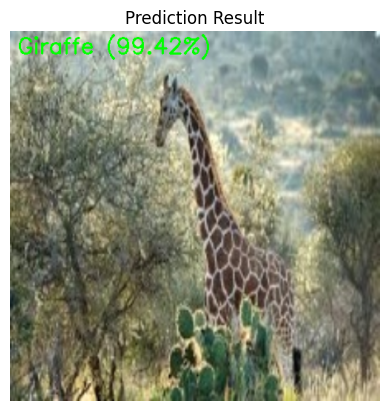

In [36]:
# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Prediction Result")
plt.show()